<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/feature_scaling/lin_reg_sales_month.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Creating data
months = np.array([1,2,3,4,5,6,7,8,9])  # Independent variable
sales = np.array([100, 120, 130, 125, 135, 130, 140, 135, 145])  # Dependent variable

# Assigning data to dataframe
df = pd.DataFrame({
    "Month": months,
    "Sales": sales
})

# Writing data to excel file
df.to_excel("Monthly_sales_data.xlsx", index=False)

Dataset:
X: [1 2 3 4 5 6 7 8 9]
Y: [100 120 130 125 135 130 140 135 145]


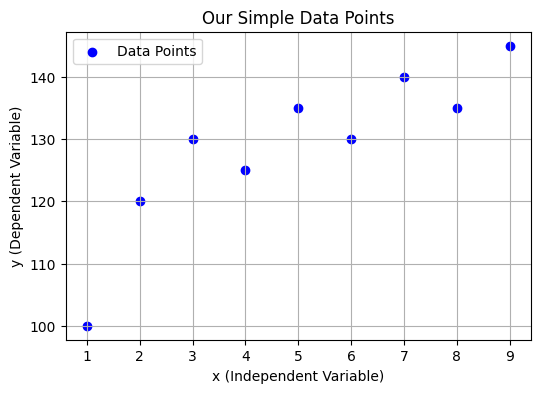

In [39]:
df = pd.read_excel("/content/drive/MyDrive/AI-python/lecture15/Monthly_sales_data.xlsx")

# Creating data to use for visualization
X = np.array(df["Month"])
Y = np.array(df["Sales"])

print("Dataset:")
print(f"X: {X}")
print(f"Y: {Y}")

# Visualization of our data points
plt.figure(figsize=(6, 4))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.title('Our Simple Data Points')
plt.xlabel('x (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.grid(True)
plt.legend()
plt.show()

In [40]:
# Calculate the means of X and Y
mean_x = np.mean(X)
mean_y = np.mean(Y)

print(f"Mean of x: {mean_x}")
print(f"Mean of y: {mean_y}\n")

# Calculate the numerator and denominator for the slope formula
numerator = np.sum((X - mean_x) * (Y - mean_y))
denominator = np.sum((X - mean_x)**2)

# Calculate the slope (m)
m = numerator / denominator

# Calculate the intercept (b)
b = mean_y - m * mean_x

print(f"Calculated Slope (m): {m:.2f}")
print(f"Calculated Intercept (b): {b:.2f}")

# Predictions using our calculated line
y_pred_math = b + m * X
print(f"\nPredicted y values (Mathematical Approach): {y_pred_math}")

Mean of x: 5.0
Mean of y: 128.88888888888889

Calculated Slope (m): 4.17
Calculated Intercept (b): 108.06

Predicted y values (Mathematical Approach): [112.22222222 116.38888889 120.55555556 124.72222222 128.88888889
 133.05555556 137.22222222 141.38888889 145.55555556]


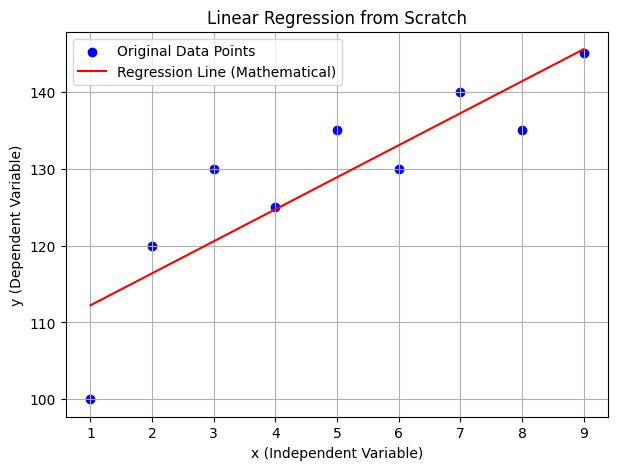

In [41]:
# Plot the original data points and the regression line
plt.figure(figsize=(7, 5))
plt.scatter(X, Y, color='blue', label='Original Data Points')
plt.plot(X, y_pred_math, color='red', label='Regression Line (Mathematical)')
plt.title('Linear Regression from Scratch')
plt.xlabel('x (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.grid(True)
plt.legend()
plt.show()

In [44]:
new_x = np.array([10, 11, 12])
predicted_y = m * new_x + b

X_new = np.concatenate((X, new_x))
Y_new = np.concatenate((Y, predicted_y))

print(f"Total months: {X_new}")
print(f"All sales data: {Y_new}")



Total months: [ 1  2  3  4  5  6  7  8  9 10 11 12]
All sales data: [100.         120.         130.         125.         135.
 130.         140.         135.         145.         149.72222222
 153.88888889 158.05555556]


In [48]:
mean_x_new = np.mean(X_new)
mean_y_new = np.mean(Y_new)

numerator = np.sum((X_new - mean_x_new) * (Y_new - mean_y_new))
denominator = np.sum((X_new - mean_x_new)**2)

m_new = numerator / denominator
b_new = mean_y_new - m_new * mean_x_new

y_pred_new = m_new * X_new + b_new


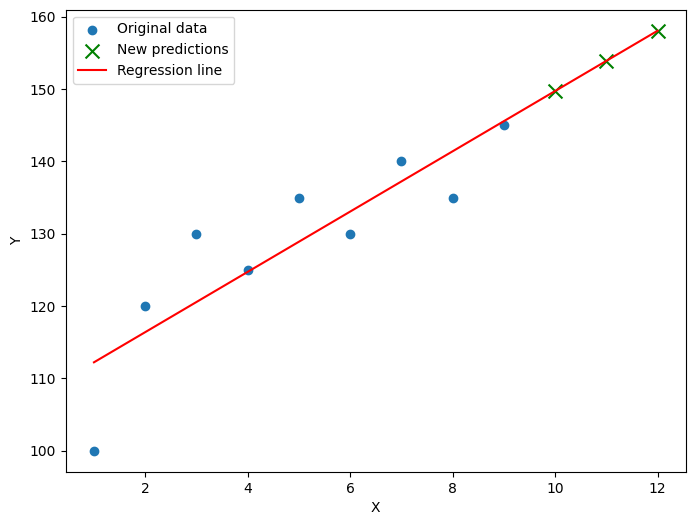

In [50]:
plt.figure(figsize=(8, 6))

# Original data
plt.scatter(X, Y, label="Original data")

# New predicted points
plt.scatter(new_x, predicted_y, color="green", marker="x", s=100, label="New predictions")

# Regression line (with new data)
# Sort for a clean line
idx = np.argsort(X_new)
plt.plot(X_new[idx], y_pred_new[idx], color="red", label="Regression line")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
